# `Recursion`

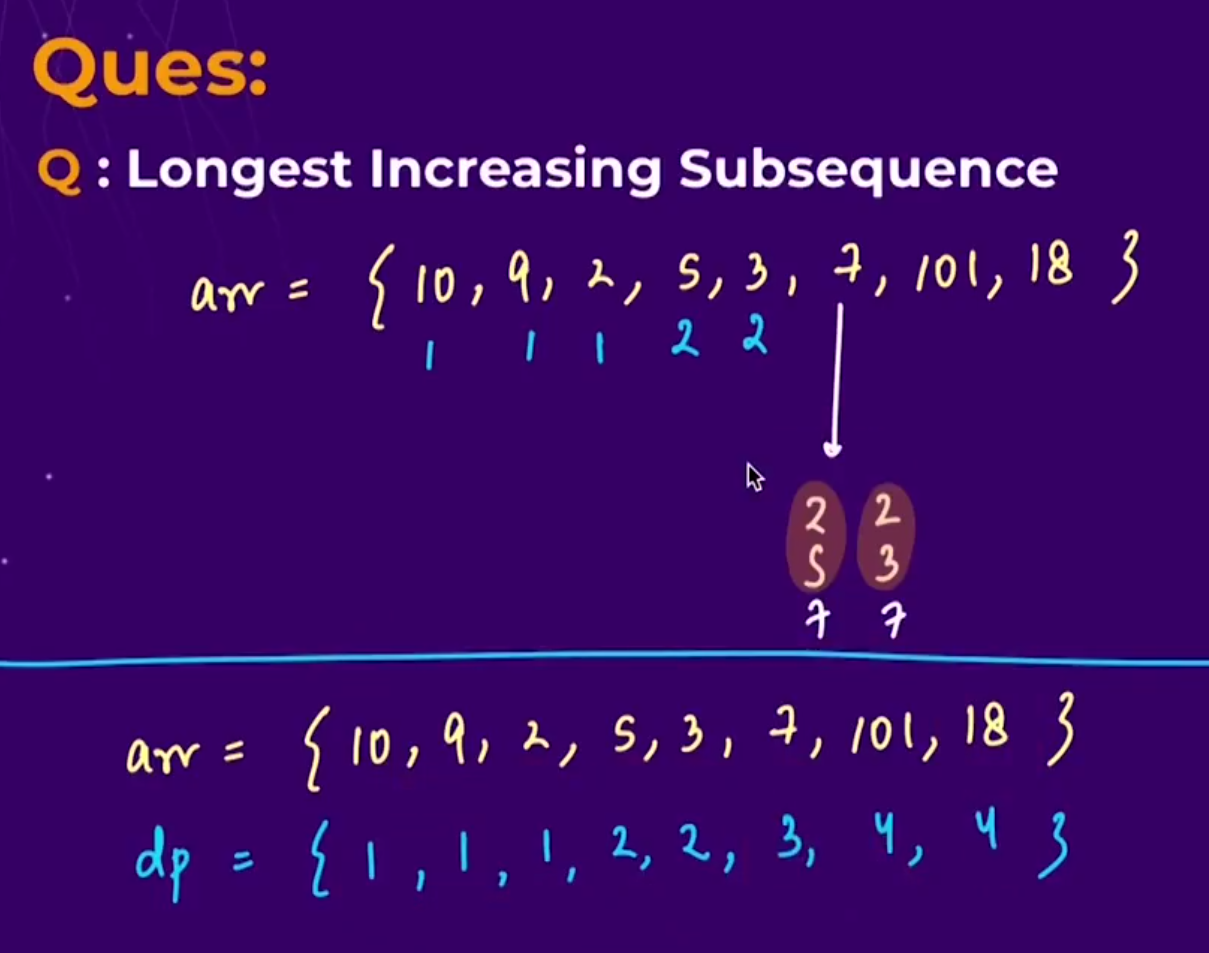

In [ ]:
# Here in DP array at every stage if arr[i] > arr[i-1] then 1 + prev_ind[i] is been added

In [2]:
from typing import List
class Solution:
    def helper(self,i,prev,nums):
        if i == len(nums):
            return 0
        
        # Skip
        not_take = self.helper(i + 1,prev,nums)

        take = 0
        if prev == -1 or nums[i] > nums[prev]:
            take = 1 + self.helper(i + 1,i,nums)    

        return max(take,not_take)
    def lengthOfLIS(self, nums: List[int]) -> int:
        return self.helper(0,-1,nums)

In [3]:
nums = [10,9,2,5,3,7,101,18]
obj = Solution()
obj.lengthOfLIS(nums)

4

In [ ]:
#                                       f(0,-1)
#                                     return = 4
#                                    /          \
#                          NOT TAKE /            \ TAKE
#                        return=4 /              \ return=2
#                                ↓                ↓
#                            f(1,-1)          1 + f(1,0)
#                           return=4           = 1 + 1 = 2
#                          /       \
#                 NOT TAKE/         \TAKE
#                     =4/             \=2
#                      ↓               ↓
#                  f(2,-1)          1+f(2,1)
#                 return=4             =2
#                 /      \
#             =3 /        \ =4
#               ↓          ↓
#           f(3,-1)      1+f(3,2)
#            return=3       =4
#             /  \
#          =2/    \=3
#           ↓      ↓
#       f(4,-1)  1+f(4,3)
#        return=3    =3
#         /  \
#       =2    =3
#        ↓     ↓
#    f(5,-1)  1+f(5,4)
#     return=2    =3
#       /  \
#     =1    =2
#      ↓     ↓
#  f(6,-1) 1+f(6,5)
#   return=1    =2

# `Memoization`

In [4]:
class Solution:
    def f(self, i, nums, dp):

        # Already calculated
        if dp[i] != -1:
            return dp[i]

        # LIS ending at i is at least 1
        ans = 1

        for j in range(i):
            if nums[i] > nums[j]:
                ans = max(ans, 1 + self.f(j, nums, dp))

        dp[i] = ans

        return dp[i]

    def lengthOfLIS(self, nums):
        n = len(nums)

        dp = [-1] * n

        ans = 0

        for i in range(n):
            ans = max(ans, self.f(i, nums, dp))

        return ans


# Driver Code
if __name__ == "__main__":
    nums = [10, 9, 2, 5, 3, 7, 101, 18]

    sol = Solution()

    print("Length of LIS:", sol.lengthOfLIS(nums))

Length of LIS: 4


# `Tabulation`

In [ ]:
# Tabulation
def LIS(nums):
    dp = [1] * len(nums)

    for i in range(1,len(nums)):
        for j in range(0,i):
            if nums[i] > nums[j]:
                if dp[j] + 1 > dp[i]:
                    dp[i] = dp[j] + 1
    
    return max(dp)

In [ ]:
nums = [10,9,2,5,3,7,101,18]
LIS(nums)

4

# `Memoization Striver`

In [2]:
from typing import List
class Solution:
    def f(self, ind, prev_ind, arr, n,dp):
        if ind == n:
            return 0

        if dp[ind][prev_ind+1]!=-1:
            return dp[ind][prev_ind+1]

        # Not Take
        lenn = self.f(ind + 1, prev_ind, arr, n,dp)

        # Take
        if prev_ind == -1 or arr[ind] > arr[prev_ind]:
            lenn = max(lenn, 1 + self.f(ind + 1, ind, arr, n,dp))

        dp[ind][prev_ind+1] = lenn
        return dp[ind][prev_ind+1]

    def lengthOfLIS(self, nums: List[int]) -> int:
        n = len(nums)
        dp = [[-1] * (n+1) for _ in range(n)]
        return self.f(0, -1, nums, n,dp)


# `Tabulation`

In [3]:
class Solution:
    def longestIncreasingSubsequence(self, arr):
        n = len(arr)

        # DP table
        dp = [[0] * (n + 1) for _ in range(n + 1)]

        # Bottom-up
        for ind in range(n - 1, -1, -1):

            for prev_ind in range(ind - 1, -2, -1):

                # Not Take
                length = dp[ind + 1][prev_ind + 1]

                # Take
                if prev_ind == -1 or arr[ind] > arr[prev_ind]:
                    length = max(
                        length,
                        1 + dp[ind + 1][ind + 1]
                    )

                dp[ind][prev_ind + 1] = length

        return dp[0][0]


# Driver Code
if __name__ == "__main__":

    arr = [10, 9, 2, 5, 3, 7, 101, 18]

    sol = Solution()

    ans = sol.longestIncreasingSubsequence(arr)

    print("Length of LIS:", ans)

Length of LIS: 4


# `Printing the subsequence`

In [5]:
def LIS(nums):
    n = len(nums)

    # dp[i] = length of LIS ending at i
    dp = [1] * n

    # parent[i] = previous index in LIS
    parent = [-1] * n

    for i in range(1, n):
        for j in range(i):

            if nums[i] > nums[j]:

                if dp[j] + 1 > dp[i]:
                    dp[i] = dp[j] + 1
                    parent[i] = j

    # Find index where LIS ends
    last = dp.index(max(dp))

    # Reconstruct LIS
    lis = []

    while last != -1:
        lis.append(nums[last])
        last = parent[last]

    # We built it backwards
    lis.reverse()

    return lis


# Driver Code
if __name__ == "__main__":
    nums = [10, 9, 2, 5, 3, 7, 101, 18]

    ans = LIS(nums)

    print("LIS:", ans)
    print("Length:", len(ans))

LIS: [2, 5, 7, 101]
Length: 4


# `Using Binary Search`

In [ ]:
# TC :- O(N*lon N)
# SC :- O(N)

class Solution:
    # Function to find the longest increasing 
    # subsequence in the given array
    def LIS(self, nums):
        n = len(nums)
        
        temp = []
        temp.append(nums[0])
        
        # Iterate on the elements of the array
        for i in range(1, n):
            
            # If the current element can be added to the subsequence
            if nums[i] > temp[-1]:
                temp.append(nums[i]) 
            
            # Otherwise
            else:
                # Index at which the current element must be placed
                ind = self.lower_bound(temp, nums[i])
                
                # Place the current element in the subsequence
                temp[ind] = nums[i]
        
        # Return the length of temporary subsequence created so far
        return len(temp)

    # Binary search to find the index of the smallest element >= target
    def lower_bound(self, temp, target):
        left, right = 0, len(temp) - 1
        while left <= right:
            mid = (left + right) // 2
            if temp[mid] < target:
                left = mid + 1
            else:
                right = mid - 1
        return left

# Example usage
nums = [10, 9, 2, 5, 3, 7, 101, 18]

# Creating an object of Solution class
sol = Solution()
lengthOfLIS = sol.LIS(nums)

print("The length of the LIS for the given array is:", lengthOfLIS)


The length of the LIS for the given array is: 4


In [7]:
1//2

0